# Latar Belakang
NYC TLC (Taxi & Limousine Commission) adalah sebuah perusahaan dibidang transportasi khususnya Taxi. Salah satu tantangan perusahaan adalah inefisiensi operasional contohnya perjalanan jarak pendek yang sering kali tidak sepadan dengan biaya operasional dan distribusi tarif belum optimal berdasarkan jarak dan waktu. 


## Pernyataan Masalah
Perusahaan ingin mengetahui **Bagaimana mengoptimalkan profitabilitas layanan taksi NYC TLC?**. Informasi ini akan membantu perusahaan untuk memetakan inefisiensi antara waktu, jara dan panjangnya perjalanan yang dipilih, perbandingan efisiensi operasional antar vendor, dan jenis perjalanan yang paling menguntungkan. 

Sebagai seorang *data analyst*, kita akan mencoba menjawab pertanyaan utama yakni: **Bagaimana mengoptimalkan struktur tarif, jarak, dan waktu tempuh untuk meningkatkan efisiensi dan profitabilitas layanan taksi NYC TLC?**

untuk menjawab pertanyaan utama diatas kita dapat membedahnya menjadi 5 pertanyaan:
1. Pada jam dan hari apa permintaan taksi paling tinggi, dan bagaimana distribusinya memengaruhi efisiensi armada?
2. Apakah ada hubungan signifikan antara jarak perjalanan, durasi, dan tarif yang dihasilkan?
3. Bagaimana efisiensi tarif per mil berbeda antara peak hours vs off-peak?
4. Vendor mana yang menghasilkan revenue per perjalanan lebih tinggi, dan apakah perbedaannya signifikan secara statistik?
5. Zona pickup mana yang paling menguntungkan, dan bagaimana rekomendasi distribusi armada berdasarkan data tersebut?

# Data


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind
import geopandas as gpd
import numpy as np


import warnings
warnings.filterwarnings("ignore")

Dataset ini berisi catatan perjalanan taksi di New York City TLC. Ada 20 kolom di dalam dataset NYC TLC Trip Record, yaitu:  

* VendorID: Kode perusahaan penyedia data perjalanan taksi
* lpep_pickup_datetime: Tanggal dan waktu saat perjalanan dimulai (penumpang naik)
* lpep_dropoff_datetime: Tanggal dan waktu saat perjalanan selesai (penumpang turun)
* Passenger_count: Jumlah penumpang dalam kendaraan (diinput oleh driver)
* Trip_distance: Jarak perjalanan dalam satuan mil berdasarkan argo taksi
* PULocationID: Kode zona lokasi saat penumpang naik
* DOLocationID: Kode zona lokasi saat penumpang turun
* RateCodeID: Kode jenis tarif yang digunakan pada akhir perjalanan
* Store_and_fwd_flag: Penanda apakah data perjalanan disimpan sementara sebelum dikirim
* Payment_type: Kode metode pembayaran
* Fare_amount: Tarif utama perjalanan berdasarkan waktu dan jarak
* Extra: Biaya tambahan seperti surcharge jam sibuk atau malam hari
* MTA_tax: Pajak tetap sebesar $0.50 yang dikenakan pada perjalanan
* Improvement_surcharge: Biaya tambahan sebesar $0.30 untuk peningkatan layanan
* Tip_amount: Jumlah tip dari penumpang (hanya tercatat untuk pembayaran kartu)
* Tolls_amount: Total biaya tol selama perjalanan
* Total_amount: Total biaya yang dibayar penumpang (tidak termasuk tip tunai)
* Trip_type: Jenis perjalanan
* ehail_fee: Biaya tambahan untuk pemesanan taksi melalui sistem elektronik (e-hailing)
* congestion_surchage: Biaya tambahan yang dikenakan untuk perjalanan di area padat (congestion zone)

Berikut 5 baris teratas dan terbawah dari dataset NYC TLC Trip Record.

In [53]:
df=pd.read_csv(r'New York City Taxi and Limousine Trip Record\NYC TLC Trip Record.csv')
display(df.head(),df.tail())

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,NaN,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,NaN,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,NaN,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,NaN,1.0,19.18,NaN,NaN,NaN
68210,2,2023-01-31 23:51:00,2023-02-01 00:07:00,NaN,NaN,256,140,NaN,5.82,23.65,0.0,0.0,2.00,0.0,NaN,1.0,29.40,NaN,NaN,NaN


## Data Understanding and Cleaning
Sebelum masuk ke dalam analisis data, kita perlu memahami dataset yang kita gunakan dalam proses pemahaman data atau *data understanding*. Dari proses ini, kita akan apakah dataset yang kita gunakan sudah siap diolah atau terdapat anomali sehinggal harus dilakukan *data cleaning*. Setiap penangan anomali yang dilakukan, akan disertai dengan justifikasi langkah yang diambil, baik secara *domain knowledge* maupun secara statistik.

Pertama, mari kita lihat informasi lengkap dari dataset NYC TLC Trip Record.

In [54]:
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')
df.info()

Jumlah baris dan kolom di dataset df adalah (68211, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14

In [55]:
display(df.describe(), df.describe(include='object'))

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,68211.000000,63887.000000,68211.000000,68211.000000,63887.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,0.0,68211.000000,68211.000000,63887.000000,63877.000000,63887.000000
mean,1.863028,1.117160,98.549735,138.429901,1.315870,8.114852,16.603545,0.825431,0.588340,2.139012,0.169627,NaN,0.951625,21.789377,1.373613,1.021933,0.726748
std,0.343820,1.372913,61.244314,76.761311,0.979054,585.105955,13.470121,1.269904,0.385819,3.052710,1.099789,NaN,0.196875,15.457115,0.508039,0.146465,1.212836
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,NaN,-1.000000,-71.500000,1.000000,1.000000,-2.750000
25%,2.000000,1.000000,74.000000,74.000000,1.000000,1.110000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,12.900000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,75.000000,138.000000,1.000000,1.850000,13.500000,0.000000,0.500000,1.600000,0.000000,NaN,1.000000,17.900000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,129.000000,219.000000,1.000000,3.210000,19.800000,1.000000,0.500000,3.330000,0.000000,NaN,1.000000,26.150000,2.000000,1.000000,2.750000
max,2.000000,99.000000,265.000000,265.000000,9.000000,120098.840000,490.000000,12.500000,2.750000,222.220000,36.050000,NaN,1.000000,491.000000,5.000000,2.000000,2.750000


,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag
count,68211,68211,63887
unique,66575,66519,2
top,2023-01-09 09:08:00,2023-01-09 00:00:00,N
freq,4,6,63579


dikarenakan masih terdapat beberapa kolom yang tidak sesuai jenis datanya, seperti `payment_type, trip_type, VendorID, RatecodeID` yang meskipun berisi data numerik tapi seharusnya berjenis data kategorikal dikarenakan angka pada kolom-kolom tersebut digunakan untuk mengidentifikasi sebuah perjalanan. Maka dari itu kita harus mengubahnya menjadi data kategorikal terlebih dahulu untuk ditampilkan selanjutnya/

In [56]:
cat = ['payment_type', 'trip_type', 'VendorID', 'RatecodeID']

df[cat] = df[cat].astype('object')

display(df.describe(), df.describe(include='object'))

,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,congestion_surcharge
count,68211.000000,68211.000000,63887.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,0.0,68211.000000,68211.000000,63887.000000
mean,98.549735,138.429901,1.315870,8.114852,16.603545,0.825431,0.588340,2.139012,0.169627,NaN,0.951625,21.789377,0.726748
std,61.244314,76.761311,0.979054,585.105955,13.470121,1.269904,0.385819,3.052710,1.099789,NaN,0.196875,15.457115,1.212836
min,1.000000,1.000000,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,NaN,-1.000000,-71.500000,-2.750000
25%,74.000000,74.000000,1.000000,1.110000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,12.900000,0.000000
50%,75.000000,138.000000,1.000000,1.850000,13.500000,0.000000,0.500000,1.600000,0.000000,NaN,1.000000,17.900000,0.000000
75%,129.000000,219.000000,1.000000,3.210000,19.800000,1.000000,0.500000,3.330000,0.000000,NaN,1.000000,26.150000,2.750000
max,265.000000,265.000000,9.000000,120098.840000,490.000000,12.500000,2.750000,222.220000,36.050000,NaN,1.000000,491.000000,2.750000


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,payment_type,trip_type
count,68211,68211,68211,63887,63887.0,63887.0,63877.0
unique,2,66575,66519,2,6.0,5.0,2.0
top,2,2023-01-09 09:08:00,2023-01-09 00:00:00,N,1.0,1.0,1.0
freq,58868,4,6,63579,62103.0,40686.0,62476.0


Berdasarkan hasil salah satu langkah pemahaman data menggungan *df.describe()*, ditemukan 3 indikasi anomali yang perlu diselidikan lebih lanjut, yakni:

1. nilai minimum dari kolom `fare_amount` yang negatif;
2. nilai maksimum dari kolom `trip_distance` yang sangat ekstrem.
3. kolom `RatecodeID` yang memiliki nilai maksimum 99 padahal jika sesuai dengan deskripsi data jenis data kolom `RatecodeID` nilai maksimum yang tertera adalah 6.

Karena itu perlu dilakukan visualisasi untuk mempermudah kita dalam memahami sebaran data sebelum dilakukan penanganan atau *data cleansing*.

**Persebaran data**

Melihat persebaran data menggunakan *value_counts()* untuk melihat persentase anomali data

Jumlah persebaran nilai negatif pada kolom `fare_amount`

In [57]:
df[df['fare_amount']<0]['fare_amount'].value_counts().sum()/df.shape[0]*100

np.float64(0.2580228995323335)

Jumlah Persebaran nilai negatif pada kolom `fare_amount` sejumlah 0,26% dari total data. Meskipun persentasenya kecil, nilai negatif pada tarif perjalanan tidak mungkin terjadi secara logika bisnis. 

Jumlah persebaran nilai maksimum percentile 99,9% untuk melihat nilai yang sangat ekstrem pada kolom `trip_distance`

In [58]:
percentile = df['trip_distance'].quantile(0.999)
display(df[df['trip_distance'] > percentile].sort_values('trip_distance', ascending=False))

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
65194,2,2023-01-11 06:02:00,2023-01-11 06:32:00,NaN,NaN,69,90,NaN,120098.84,46.82,0.0,0.0,2.00,0.00,NaN,1.0,52.57,NaN,NaN,NaN
67926,2,2023-01-29 18:03:00,2023-01-29 18:21:00,NaN,NaN,244,263,NaN,68796.82,24.90,0.0,0.0,5.73,0.00,NaN,1.0,34.38,NaN,NaN,NaN
66581,2,2023-01-20 09:06:00,2023-01-20 09:31:00,NaN,NaN,35,181,NaN,44003.31,26.33,0.0,0.0,0.50,0.00,NaN,0.3,27.13,NaN,NaN,NaN
64609,2,2023-01-06 07:27:00,2023-01-06 07:30:00,NaN,NaN,41,74,NaN,43392.12,12.02,0.0,0.0,2.60,0.00,NaN,1.0,15.62,NaN,NaN,NaN
65846,2,2023-01-15 05:46:00,2023-01-15 06:04:00,NaN,NaN,82,138,NaN,10480.36,20.01,0.0,0.0,4.20,0.00,NaN,1.0,25.21,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40820,1,2023-01-21 03:36:32,2023-01-21 03:37:20,N,5.0,265,265,1.0,28.80,0.00,0.0,0.0,0.00,0.00,NaN,0.0,0.00,4.0,2.0,0.0
40789,1,2023-01-21 02:46:13,2023-01-21 03:27:19,N,5.0,112,265,1.0,28.80,0.00,0.0,0.0,0.00,6.55,NaN,0.0,6.55,2.0,2.0,0.0
16175,2,2023-01-09 14:05:14,2023-01-09 18:18:55,N,5.0,134,95,1.0,28.67,45.00,0.0,0.0,0.00,0.00,NaN,1.0,46.00,2.0,1.0,0.0
66911,2,2023-01-22 16:13:00,2023-01-22 16:24:00,NaN,NaN,181,52,NaN,28.65,12.23,0.0,0.0,2.65,0.00,NaN,1.0,15.88,NaN,NaN,NaN


nilai teratas pada kolom `trip_distance` sangat tidak memungkinan terjadi dengan waktu yang singkat seperti jarak tempuh 120.098 mil dengan durasi hanya 30 menit (06:02 → 06:32) yang seharusnya mustahil terjadi serta pada baris dengan nilai ekstrem tersebut semuanya memiliki `RatecodeID`, `store_and_fwd_flag`, dan `passenger_count` bernilai NaN, hal ini mengindikasikan kalau data-data tersebut corrupt dan perjalanan tidak valid

Melihat Persebaran data menggunakan boxplot untuk melihat posisi outlier

<Axes: >

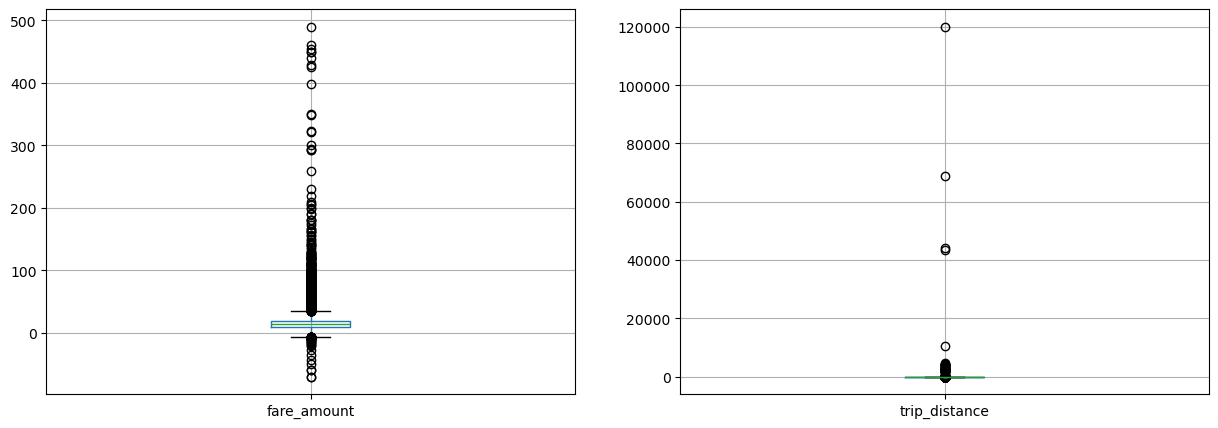

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df.boxplot(column='fare_amount', ax=axes[0])
df.boxplot(column='trip_distance', ax=axes[1])

Secara umum, berdasarkan hasil eksplorasi data (boxplot dan gambaran data umum pada *df.describe()*), dapat diperoleh beberapa temuan sebagai berikut:

1. Outlier pada `trip_distance`  
Terdapat nilai yang tidak wajar pada kolom `trip_distance`, dengan nilai maksimum mencapai 120.098 mil, yang mengindikasikan adanya outlier ekstrem.
2. Nilai tidak logis pada `fare_amount`  
Ditemukan nilai minimum negatif pada kolom `fare_amount`, padahal secara logika tarif perjalanan tidak mungkin bernilai negatif.
3. Nilai tidak valid pada `passenger_count`  
Terdapat data dengan nilai `passenger_count` = 0, yang tidak sesuai karena perjalanan seharusnya memiliki minimal satu penumpang.
4. Kolom `ehail_fee` tidak memiliki nilai (kosong secara keseluruhan), sehingga kemungkinan tidak digunakan atau tidak relevan dalam dataset ini.


**Missing Value**

melihat persentase *missing value* dari tiap kolom 

In [60]:
df.isna().sum()/df.shape[0]*100

VendorID                   0.000000
lpep_pickup_datetime       0.000000
lpep_dropoff_datetime      0.000000
store_and_fwd_flag         6.339154
RatecodeID                 6.339154
PULocationID               0.000000
DOLocationID               0.000000
passenger_count            6.339154
trip_distance              0.000000
fare_amount                0.000000
extra                      0.000000
mta_tax                    0.000000
tip_amount                 0.000000
tolls_amount               0.000000
ehail_fee                100.000000
improvement_surcharge      0.000000
total_amount               0.000000
payment_type               6.339154
trip_type                  6.353814
congestion_surcharge       6.339154
dtype: float64

Melihat jumlah data yang terduplikasi pada tiap kolom

In [61]:
df.duplicated().sum()

np.int64(0)

melihat perseberan data *missing value* pada tiap kolom untuk dipetakan apakah data tersebut saling berkorelasi

<Axes: >

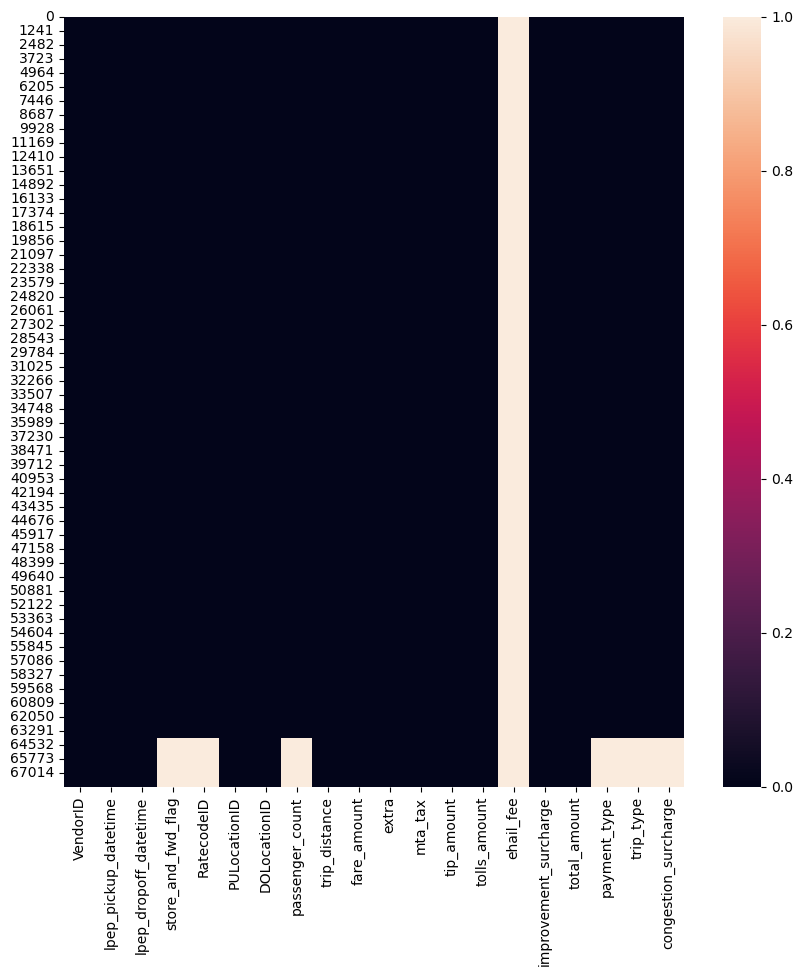

In [62]:
plt.figure(figsize=(10,10))
sns.heatmap(df[['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge',
       'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge']].isna())

Secara garis besar:  
* *missing value* di kolom `store_and_fwd_flag`,`congestion_surcharge`,`payment_type`,`passenger_count`,`RatecodeID` memiliki presentase yang sama persis yakni 6,33%.
* *missing value* di kolom `trip_type` memiliki persentase yang hampir mirip dengan kelompok kolom sebelumnya yakni 6,35%.
* *missing value* di kolom `ehail_fee` yang memiliki persentase 100% atau tidak terdapat value sama sekali pada kolom tersebut.

Ada 3 cara untuk menangani *missing value*:
* pertama, menghapus baris yang berisi *missing value*. hal ini dilakukan karena jumlah missing value yang tergolong kecil yakni sebesar 6,33% dan memiliki korelasi antar kolom yang mengindikasikan terdapat salah perekaman dalam sistem atau *data corrupt*.
* kedua, menghapus kolom yang berisikan *missing value* seluruhnya.
* ketiga, menghapus data yang memiliki outlier ekstrem.

Kita sudah melihat gambaran kasar anomali di dalam data kita, sekarang, mari kita lihat dan tangani tiap-tiap anomali secara lebih jauh.  


Pertama kita akan melakukan penghapusan pada kolom `ehail_fee` dikarenakan kolom tersebut memiliki 100% data null dan tidak berkaitan dengan uji analisis.

In [63]:
df = df.drop('ehail_fee', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  object 
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  object 
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14  improvement_surcharge  68211 non-null  float64
 15  to

Dari analisis di atas, kita sudah tau bahwa *missing value* `congestion_surcharge`,`payment_type`,`passenger_count`, `RatecodeID` serta `trip_type` saling berkaitan. Maka, kita akan memutuskan untuk melakukan penghapusan data pada kolom-kolom ini secara bersamaan.  

Data sebelum dilakukan penghapusan

In [64]:
display(df.describe(), df.describe(include='object'))

,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,68211.000000,68211.000000,63887.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,68211.000000,63887.000000
mean,98.549735,138.429901,1.315870,8.114852,16.603545,0.825431,0.588340,2.139012,0.169627,0.951625,21.789377,0.726748
std,61.244314,76.761311,0.979054,585.105955,13.470121,1.269904,0.385819,3.052710,1.099789,0.196875,15.457115,1.212836
min,1.000000,1.000000,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,-1.000000,-71.500000,-2.750000
25%,74.000000,74.000000,1.000000,1.110000,9.300000,0.000000,0.500000,0.000000,0.000000,1.000000,12.900000,0.000000
50%,75.000000,138.000000,1.000000,1.850000,13.500000,0.000000,0.500000,1.600000,0.000000,1.000000,17.900000,0.000000
75%,129.000000,219.000000,1.000000,3.210000,19.800000,1.000000,0.500000,3.330000,0.000000,1.000000,26.150000,2.750000
max,265.000000,265.000000,9.000000,120098.840000,490.000000,12.500000,2.750000,222.220000,36.050000,1.000000,491.000000,2.750000


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,payment_type,trip_type
count,68211,68211,68211,63887,63887.0,63887.0,63877.0
unique,2,66575,66519,2,6.0,5.0,2.0
top,2,2023-01-09 09:08:00,2023-01-09 00:00:00,N,1.0,1.0,1.0
freq,58868,4,6,63579,62103.0,40686.0,62476.0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  object 
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  object 
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14  improvement_surcharge  68211 non-null  float64
 15  to

In [66]:
df.dropna(subset=['passenger_count',
                  'RatecodeID',
                  'payment_type',
                  'trip_type',
                  'congestion_surcharge'], inplace=True)

Data setelah dilakukan penghapusan

In [67]:
display(df.describe(), df.describe(include='object'))

,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000,63877.000000
mean,97.730200,138.308797,1.315920,2.576974,16.074491,0.880473,0.626951,2.041507,0.144182,0.949187,21.200955,0.726862
std,60.173501,76.883640,0.979123,6.760261,13.277144,1.292861,0.366919,2.998734,1.012740,0.201782,15.131310,1.212897
min,1.000000,1.000000,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,-1.000000,-71.500000,-2.750000
25%,74.000000,74.000000,1.000000,1.100000,9.000000,0.000000,0.500000,0.000000,0.000000,1.000000,12.600000,0.000000
50%,75.000000,138.000000,1.000000,1.800000,12.800000,0.000000,0.500000,1.400000,0.000000,1.000000,17.500000,0.000000
75%,117.000000,220.000000,1.000000,3.050000,19.100000,1.000000,0.500000,3.220000,0.000000,1.000000,25.500000,2.750000
max,265.000000,265.000000,9.000000,1571.970000,490.000000,12.500000,2.750000,222.220000,36.050000,1.000000,491.000000,2.750000


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,payment_type,trip_type
count,63877,63877,63877,63877,63877.0,63877.0,63877.0
unique,2,62665,62602,2,5.0,5.0,2.0
top,2,2023-01-07 23:58:06,2023-01-06 00:00:00,N,1.0,1.0,1.0
freq,54672,4,6,63569,62103.0,40676.0,62476.0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63877 entries, 0 to 63886
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               63877 non-null  object 
 1   lpep_pickup_datetime   63877 non-null  object 
 2   lpep_dropoff_datetime  63877 non-null  object 
 3   store_and_fwd_flag     63877 non-null  object 
 4   RatecodeID             63877 non-null  object 
 5   PULocationID           63877 non-null  int64  
 6   DOLocationID           63877 non-null  int64  
 7   passenger_count        63877 non-null  float64
 8   trip_distance          63877 non-null  float64
 9   fare_amount            63877 non-null  float64
 10  extra                  63877 non-null  float64
 11  mta_tax                63877 non-null  float64
 12  tip_amount             63877 non-null  float64
 13  tolls_amount           63877 non-null  float64
 14  improvement_surcharge  63877 non-null  float64
 15  total_a

In [69]:
df[df['RatecodeID'] == 99]['RatecodeID'].value_counts().sum()

np.int64(0)

pengecekan kolom `RatecodeID` yang bernilai 99 atau unknown setelah dilakukan penghapusan terlihat kolom `RatecodeID` dengan nilai 99 telah ikut terhapus juga

In [70]:
display(df[df['fare_amount'] < 1])

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
662,2,2023-01-01 14:58:13,2023-01-01 14:58:39,N,1.0,75,74,2.0,0.17,-3.0,0.0,-0.5,0.0,0.0,-1.0,-4.5,3.0,1.0,0.0
898,2,2023-01-01 17:24:52,2023-01-01 17:25:12,N,1.0,193,193,1.0,0.00,-3.0,0.0,-0.5,0.0,0.0,-1.0,-4.5,4.0,1.0,0.0
1317,2,2023-01-02 02:05:08,2023-01-02 02:12:57,N,1.0,129,82,1.0,0.64,-8.6,-1.0,-0.5,0.0,0.0,-1.0,-11.1,3.0,1.0,0.0
1581,2,2023-01-02 10:29:51,2023-01-02 10:30:34,N,1.0,264,264,1.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1686,2,2023-01-02 12:56:53,2023-01-02 13:00:10,N,1.0,75,75,1.0,0.77,-4.5,0.0,-0.5,0.0,0.0,-0.3,-5.3,4.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63358,2,2023-01-31 18:39:16,2023-01-31 18:39:29,N,1.0,130,130,3.0,0.05,-3.0,-2.5,-0.5,0.0,0.0,-1.0,-7.0,4.0,1.0,0.0
63544,2,2023-01-31 19:06:18,2023-01-31 19:06:46,N,1.0,75,75,2.0,0.08,-3.0,-2.5,-0.5,0.0,0.0,-1.0,-7.0,3.0,1.0,0.0
63655,2,2023-01-31 20:29:00,2023-01-31 20:29:14,N,1.0,74,74,1.0,0.00,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8,3.0,1.0,0.0
63807,2,2023-01-31 22:44:16,2023-01-31 22:45:18,N,1.0,256,256,1.0,0.15,-3.7,-1.0,-0.5,0.0,0.0,-1.0,-6.2,3.0,1.0,0.0


pengecekan kolom `fare_amount` yang bernilai negatif atau 0 setelah dilakukan penghapusan terlihat kolom `fare_amount` dengan nilai negatif atau 0 tidak ikut terhapus meskipun tidak banyak jumlahnya

In [71]:
df = df[df['fare_amount'] >= 1]

penghapusan nilai anomali dari kolom `fare_amount` yang bernilai 0 atau negatif karena tidak masuk dengan logika bisnis sejumlah 265 baris

In [72]:
display(df[df['trip_distance'] == 0])

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.0,7.2,1.0,0.5,1.94,0.0,1.0,11.64,1.0,1.0,0.0
58,2,2023-01-01 00:57:15,2023-01-01 01:00:15,N,1.0,75,75,1.0,0.0,4.4,1.0,0.5,1.38,0.0,1.0,8.28,1.0,1.0,0.0
99,2,2023-01-01 01:27:36,2023-01-01 01:27:43,N,5.0,168,168,0.0,0.0,20.0,0.0,0.0,0.00,0.0,1.0,21.00,1.0,2.0,0.0
107,2,2023-01-01 01:11:13,2023-01-01 01:11:36,N,1.0,7,7,1.0,0.0,3.0,1.0,0.5,9.00,0.0,1.0,14.50,1.0,1.0,0.0
115,2,2023-01-01 01:52:58,2023-01-01 01:53:00,N,1.0,264,264,1.0,0.0,3.0,1.0,0.5,21.50,0.0,0.3,26.30,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63756,2,2023-01-31 21:56:14,2023-01-31 21:56:16,N,5.0,97,264,1.0,0.0,12.0,0.0,0.0,0.00,0.0,1.0,13.00,1.0,2.0,0.0
63798,2,2023-01-31 22:19:41,2023-01-31 22:27:59,N,1.0,42,152,1.0,0.0,8.6,1.0,0.5,0.00,0.0,1.0,11.10,2.0,1.0,0.0
63813,2,2023-01-31 22:29:03,2023-01-31 22:35:11,N,1.0,95,95,2.0,0.0,7.2,1.0,0.5,0.00,0.0,1.0,9.70,2.0,1.0,0.0
63833,2,2023-01-31 22:43:19,2023-01-31 22:46:09,N,5.0,130,130,1.0,0.0,10.0,0.0,0.0,0.00,0.0,1.0,11.00,2.0,2.0,0.0


pengecekan kolom `trip_distance` yang bernilai 0 ternyata masih ada meskipun setelah dilakukan penghapusan, hal ini mengindikasikan bahwa kolom `trip_distance` yang bernilai 0 tidak serta merta dikarenakan eror sistem atau terjadi corrupt data seperti penyebab nilai anomali yang lain sehingga masih harus dilakukan pengecekan ulang.

In [73]:
display(df[(df['PULocationID'].isin([264, 265]) | df['DOLocationID'].isin([264, 265])) & (df['trip_distance'] == 0)])

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
115,2,2023-01-01 01:52:58,2023-01-01 01:53:00,N,1.0,264,264,1.0,0.0,3.0,1.0,0.5,21.5,0.0,0.3,26.3,1.0,1.0,0.0
166,2,2023-01-01 02:37:12,2023-01-01 02:37:15,N,5.0,51,264,3.0,0.0,40.0,0.0,0.0,0.0,0.0,1.0,41.0,1.0,2.0,0.0
173,2,2023-01-01 02:37:12,2023-01-01 02:37:15,N,5.0,260,264,1.0,0.0,20.0,0.0,0.0,4.2,0.0,1.0,25.2,1.0,2.0,0.0
186,2,2023-01-01 03:01:54,2023-01-01 03:01:56,N,5.0,129,264,1.0,0.0,12.0,0.0,0.0,0.0,0.0,1.0,13.0,1.0,2.0,0.0
227,2,2023-01-01 03:11:48,2023-01-01 03:12:31,N,5.0,7,264,1.0,0.0,12.0,0.0,0.0,2.6,0.0,1.0,15.6,1.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61912,1,2023-01-31 08:16:40,2023-01-31 08:45:26,N,1.0,264,264,1.0,0.0,19.5,0.0,1.5,0.0,0.0,1.0,21.0,1.0,1.0,0.0
62888,1,2023-01-31 15:46:19,2023-01-31 16:12:46,N,1.0,175,265,1.0,0.0,26.2,0.0,1.5,0.0,0.0,1.0,27.7,1.0,1.0,0.0
63725,2,2023-01-31 21:24:02,2023-01-31 21:24:03,N,5.0,264,264,1.0,0.0,35.0,0.0,0.0,0.0,0.0,1.0,36.0,1.0,2.0,0.0
63756,2,2023-01-31 21:56:14,2023-01-31 21:56:16,N,5.0,97,264,1.0,0.0,12.0,0.0,0.0,0.0,0.0,1.0,13.0,1.0,2.0,0.0


berikut adalah hasil pengecekan data anomali pada kolom `trip_distance` yang berisikan nilai 0 ternyata sebanyak 346 baris yang memiliki nilai 264 atau 265 pada kolom `PULocationID` dan/atau `DOLocationID` yang mengindikasikan salah rekam pada gps sehingga tidak dapat ditindak lanjut dan lebih baik dihapus saja dikarenakan kita tidak dapat memperkirakan dimana titik naik penumpang dan titik turun penumpang serta memiliki jumlah data yang sedikit.

In [74]:
df = df[((df['PULocationID'].isin([264, 265]) == False) & (df['DOLocationID'].isin([264, 265]) == False)) | (df['trip_distance'] != 0)]

penghapusan data anomali pada kolom `trip_distance` yang berisikan nilai 0 ternyata sebanyak 346 baris yang memiliki nilai 264 atau 265 pada kolom `PULocationID` dan/atau `DOLocationID`.

In [75]:
#Isi trip_distance = 0 dengan estimasi jarak

zone_lookup = pd.read_csv(r'New York City Taxi and Limousine Trip Record\taxi_zone_lookup.csv')
zones = gpd.read_file(r'New York City Taxi and Limousine Trip Record\NYC Taxi Zones.geojson')
zones = zones.to_crs(epsg=3857)
zones['centroid'] = zones.geometry.centroid

zone_centroid = dict(zip(zones['location_id'].astype(int), zones['centroid']))

def hitung_jarak(row):
    pu = zone_centroid.get(int(row['PULocationID']))
    do = zone_centroid.get(int(row['DOLocationID']))
    if pu and do:
        return pu.distance(do) * 0.000621371  # meter → mil
    return np.nan

mask = df['trip_distance'] == 0

df.loc[mask, 'trip_distance'] = df[mask].apply(hitung_jarak, axis=1)
display(zone_lookup)
display(df[df['trip_distance'] < 0.1][['PULocationID', 'DOLocationID', 'trip_distance']].head(10))


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


,PULocationID,DOLocationID,trip_distance
58,75,75,0.00
99,168,168,0.00
104,179,179,0.01
107,7,7,0.00
146,169,169,0.01
163,36,36,0.09
169,157,157,0.00
185,223,223,0.00
193,70,70,0.00
208,157,157,0.03


Memastikan `trip_distance` yang 0 dikarenakan memang tidak ada perpindahan taksi serta mengisi nilai dari kolom `trip_distance` yang seharusnya tidak, data pada trip distance diisi menggunakan data tambahan yang didapatkan pada sumber berikut:
1. taxi_zone_lookup : [Refrensi kolom `RatecodeID`](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)
2. taxi_zones       : [Refrensi jarak antar daerah pada NYC](https://www.kaggle.com/datasets/mxruedag/tlc-nyc-taxi-zones)

In [76]:
print(f'Jumlah data sebelum cleaning: 68211')
print(f'Jumlah data setelah cleaning: {len(df)}')
print(f'Data yang dihapus: {68211 - len(df)} baris ({(68211 - len(df))/68211*100:.2f}%)')

Jumlah data sebelum cleaning: 68211
Jumlah data setelah cleaning: 63266
Data yang dihapus: 4945 baris (7.25%)


Data anomali yang dihapus pada dataset sebanyak **4.945 baris (7,25%)**. Penghapusan ini mencakup **outlier ekstrem, data kategorikal yang tidak terdefinisi dalam data description, serta data yang tidak masuk akal secara logika bisnis**. Hal ini mengindikasikan bahwa data tersebut kemungkinan besar merupakan **kesalahan input sistem atau data yang corrupt**, sehingga penghapusannya dapat dibenarkan mengingat proporsinya relatif kecil.

Meskipun demikian, masih terdapat beberapa data yang tidak wajar, seperti nilai **0 pada kolom `trip_distance`**. Setelah dilakukan pengecekan, sebagian data memang harus dihapus karena tidak mencerminkan kondisi nyata, sementara sebagian lainnya masih dapat dipertahankan dengan **penyesuaian berdasarkan referensi tambahan** agar tetap merepresentasikan kondisi di lapangan.


## Transformasi Data

dalam Transformasi Data  ini kita menambahkan kolom berdasarkan kolom yang sudah ada untuk memudahkan kita membaca kolom dan menganalisi data.

In [77]:
# Durasi perjalanan dalam menit
df['trip_duration_min'] = (
    pd.to_datetime(df['lpep_dropoff_datetime']) - 
    pd.to_datetime(df['lpep_pickup_datetime'])
).dt.total_seconds() / 60

# Tarif per mil
df['fare_per_mile'] = np.where(df['trip_distance'] == 0, 0, df['fare_amount'] / df['trip_distance'])

# Revenue per menit
df['revenue_per_minute'] = df['total_amount'] / df['trip_duration_min']
df['revenue_per_minute'] = np.where(df['trip_duration_min'] == 0, 0, df['total_amount'] / df['trip_duration_min'])

# Jam pickup
df['pickup_hour'] = pd.to_datetime(df['lpep_pickup_datetime']).dt.hour

# Nama hari pickup
df['pickup_day'] = pd.to_datetime(df['lpep_pickup_datetime']).dt.day_name()

# Apakah jam sibuk (peak hour)?
# Peak hour = pagi 07-09 dan sore 15-19
df['is_peak_hour'] = df['pickup_hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (15 <= x <= 19) else 0
)

# Apakah akhir pekan?
df['is_weekend'] = df['pickup_day'].isin(['Saturday', 'Sunday']).astype(int)

# Estimasi kecepatan rata-rata
# Proksi kondisi lalu lintas: jarak dibagi durasi dalam jam
df['speed_mph'] = df['trip_distance'] / (df['trip_duration_min'] / 60)
df['speed_mph'] = np.where(df['trip_duration_min'] == 0, 0, df['trip_distance'] / (df['trip_duration_min'] / 60))

# Verifikasi hasil
print("Kolom baru yang ditambahkan:")
df[['trip_duration_min', 'fare_per_mile', 'revenue_per_minute',
          'pickup_hour', 'pickup_day', 'is_peak_hour', 
          'is_weekend', 'speed_mph']].describe()


Kolom baru yang ditambahkan:


,trip_duration_min,fare_per_mile,revenue_per_minute,pickup_hour,is_peak_hour,is_weekend,speed_mph
count,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000
mean,17.963119,10.774772,5.479482,13.914836,0.508045,0.246088,14.058438
std,76.665133,141.997577,65.448467,5.192133,0.499939,0.430734,105.197426
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.150000,5.461538,1.340925,10.000000,0.000000,0.000000,8.372093
50%,11.150000,6.585366,1.621634,15.000000,1.000000,0.000000,10.525424
75%,16.916667,7.916667,2.024113,18.000000,1.000000,0.000000,13.613706
max,1438.933333,19950.000000,5530.800000,23.000000,1.000000,1.000000,11700.000000


## Data Analysis

Sekarang kita sudah mendapatkan data yang *bersih* dan telah dilakukan transformasi sehingga data lebih siap untuk dianalisis

## Analisis Deskriptif

Analisis deskriptif bertujuan untuk memahami karakteristik data secara menyeluruh

In [78]:
display(df.describe(), df.describe(include='object'))

,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration_min,fare_per_mile,revenue_per_minute,pickup_hour,is_peak_hour,is_weekend,speed_mph
count,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000,63266.000000
mean,97.235593,137.733285,1.316552,2.748495,16.121146,0.890573,0.631619,2.047382,0.144457,0.955935,21.281295,0.733795,17.963119,10.774772,5.479482,13.914836,0.508045,0.246088,14.058438
std,59.597858,76.534191,0.980385,6.834251,13.114012,1.292518,0.360238,2.942678,1.013599,0.171263,14.936901,1.216284,76.665133,141.997577,65.448467,5.192133,0.499939,0.430734,105.197426
min,3.000000,1.000000,0.000000,0.000000,1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,2.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,74.000000,1.000000,1.180000,9.300000,0.000000,0.500000,0.000000,0.000000,1.000000,12.620000,0.000000,7.150000,5.461538,1.340925,10.000000,0.000000,0.000000,8.372093
50%,75.000000,138.000000,1.000000,1.880000,12.800000,0.000000,0.500000,1.460000,0.000000,1.000000,17.500000,0.000000,11.150000,6.585366,1.621634,15.000000,1.000000,0.000000,10.525424
75%,116.000000,217.000000,1.000000,3.200000,19.100000,1.000000,0.500000,3.220000,0.000000,1.000000,25.500000,2.750000,16.916667,7.916667,2.024113,18.000000,1.000000,0.000000,13.613706
max,265.000000,265.000000,9.000000,1571.970000,490.000000,12.500000,1.500000,222.220000,36.050000,1.000000,491.000000,2.750000,1438.933333,19950.000000,5530.800000,23.000000,1.000000,1.000000,11700.000000


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,payment_type,trip_type,pickup_day
count,63266,63266,63266,63266,63266.0,63266.0,63266.0,63266
unique,2,62247,62175,2,5.0,5.0,2.0,7
top,2,2023-01-20 07:32:51,2023-01-22 00:00:00,N,1.0,1.0,1.0,Tuesday
freq,54183,3,6,62983,61714.0,40374.0,62073.0,10501


**Distribusi Kolom Numerik**

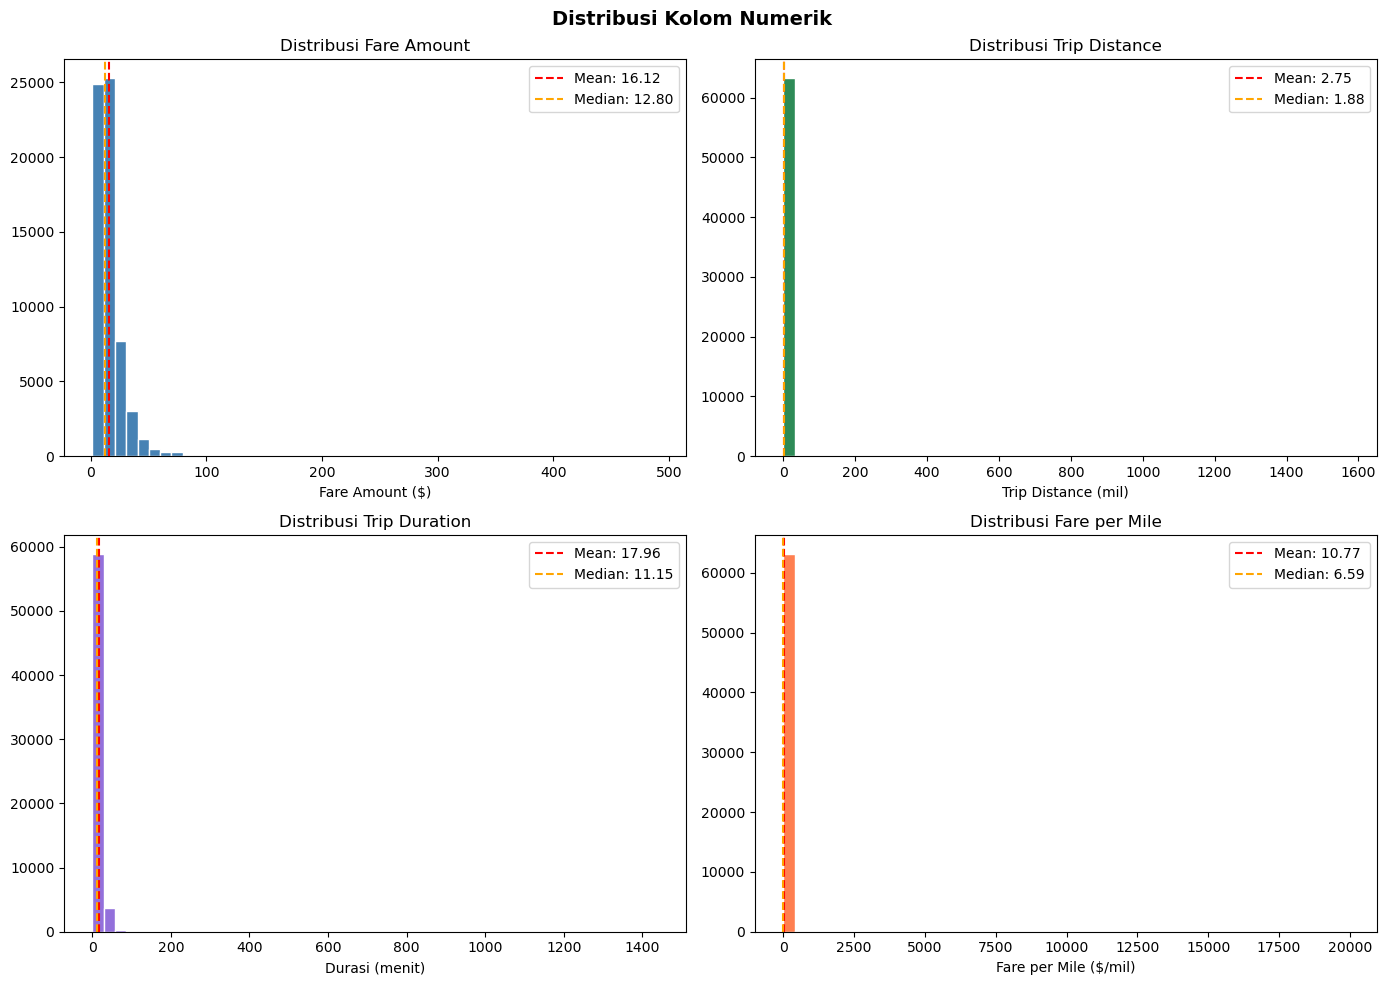

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Kolom Numerik ', fontsize=14, fontweight='bold')

# fare_amount
axes[0,0].hist(df['fare_amount'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(df['fare_amount'].mean(), color='red', linestyle='--', label=f"Mean: {df['fare_amount'].mean():.2f}")
axes[0,0].axvline(df['fare_amount'].median(), color='orange', linestyle='--', label=f"Median: {df['fare_amount'].median():.2f}")
axes[0,0].set_title('Distribusi Fare Amount')
axes[0,0].set_xlabel('Fare Amount ($)')
axes[0,0].legend()

# trip_distance
axes[0,1].hist(df['trip_distance'], bins=50, color='seagreen', edgecolor='white')
axes[0,1].axvline(df['trip_distance'].mean(), color='red', linestyle='--', label=f"Mean: {df['trip_distance'].mean():.2f}")
axes[0,1].axvline(df['trip_distance'].median(), color='orange', linestyle='--', label=f"Median: {df['trip_distance'].median():.2f}")
axes[0,1].set_title('Distribusi Trip Distance')
axes[0,1].set_xlabel('Trip Distance (mil)')
axes[0,1].legend()

# trip_duration_min
axes[1,0].hist(df['trip_duration_min'], bins=50, color='mediumpurple', edgecolor='white')
axes[1,0].axvline(df['trip_duration_min'].mean(), color='red', linestyle='--', label=f"Mean: {df['trip_duration_min'].mean():.2f}")
axes[1,0].axvline(df['trip_duration_min'].median(), color='orange', linestyle='--', label=f"Median: {df['trip_duration_min'].median():.2f}")
axes[1,0].set_title('Distribusi Trip Duration')
axes[1,0].set_xlabel('Durasi (menit)')
axes[1,0].legend()

# fare_per_mile
axes[1,1].hist(df['fare_per_mile'], bins=50, color='coral', edgecolor='white')
axes[1,1].axvline(df['fare_per_mile'].mean(), color='red', linestyle='--', label=f"Mean: {df['fare_per_mile'].mean():.2f}")
axes[1,1].axvline(df['fare_per_mile'].median(), color='orange', linestyle='--', label=f"Median: {df['fare_per_mile'].median():.2f}")
axes[1,1].set_title('Distribusi Fare per Mile')
axes[1,1].set_xlabel('Fare per Mile ($/mil)')
axes[1,1].legend()

plt.tight_layout()
plt.show()


Distribusi `fare_amount` cenderung *right-skewed*, dapat dilihat dari nilai mean yang lebih besar dibanding median. Dilihat dari quantile 25% dan 75%, mayoritas tarif perjalanan itu ada di kisaran $9–$20.

Selain itu, ada beberapa nilai ekstrem di sisi kanan distribusi (outlier) yang kemungkinan berasal dari perjalanan jarak jauh atau tarif tertentu, sehingga bikin rata-rata (mean) jadi lebih tinggi. Karena kondisi ini, median lebih cocok dipakai sebagai ukuran pusat data dibandingkan mean.


**Distribusi Kolom Kategorikal**

In [80]:
# VendorID
df['VendorID'].value_counts()
df['VendorID'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'


VendorID
2    85.64%
1    14.36%
Name: proportion, dtype: object

In [81]:
# Payment Type
payment_map = {1:'Credit Card', 2:'Cash', 3:'No Charge', 4:'Dispute', 5:'Unknown'}
df['payment_type'].map(payment_map).value_counts()
df['payment_type'].map(payment_map).value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

payment_type
Credit Card    63.82%
Cash           35.57%
No Charge       0.52%
Dispute          0.1%
Unknown          0.0%
Name: proportion, dtype: object

In [82]:
# RatecodeID
rate_map = {1:'Standard', 2:'JFK', 3:'Newark', 4:'Nassau/Westchester', 5:'Negotiated', 6:'Group Ride'}
df['RatecodeID'].map(rate_map).value_counts()
df['RatecodeID'].map(rate_map).value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

RatecodeID
Standard              97.55%
Negotiated             2.08%
JFK                    0.24%
Nassau/Westchester     0.08%
Newark                 0.05%
Name: proportion, dtype: object

In [83]:
# Trip Type
trip_map = {1:'Street-hail', 2:'Dispatch'}
df['trip_type'].map(trip_map).value_counts()
df['trip_type'].map(trip_map).value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

trip_type
Street-hail    98.11%
Dispatch        1.89%
Name: proportion, dtype: object

Dari distribusi kolom kategorikal, **VendorID 2 (VeriFone)** terlihat jauh lebih mendominasi dibanding **VendorID 1 (CMT)**. Untuk metode pembayaran paling banyak menggunakan kartu kredit dan disusul cash. Tapi sebagai catatan, transaksi cash biasanya tidak mencatat tip secara otomatis, jadi ada kemungkinan total pendapatan driver yang kelihatan jadi lebih kecil dari yang sebenarnya.

Di sisi lain, **RatecodeID 1 (Standard Rate)** mendominasi hampir semua perjalanan, yang berarti mayoritas trip itu perjalanan reguler dalam kota. Selain itu, **trip type** juga lebih banyak *street-hail* dibanding *dispatch*, menunjukkan kalau layanan NYC TLC masih sangat bergantung dengan penumpang yang langsung naik dari jalan.


**Analisis Demand Pattern**

analisis berikut digunakan untuk menggambarkan pola penggunaan jasa NYC TLC

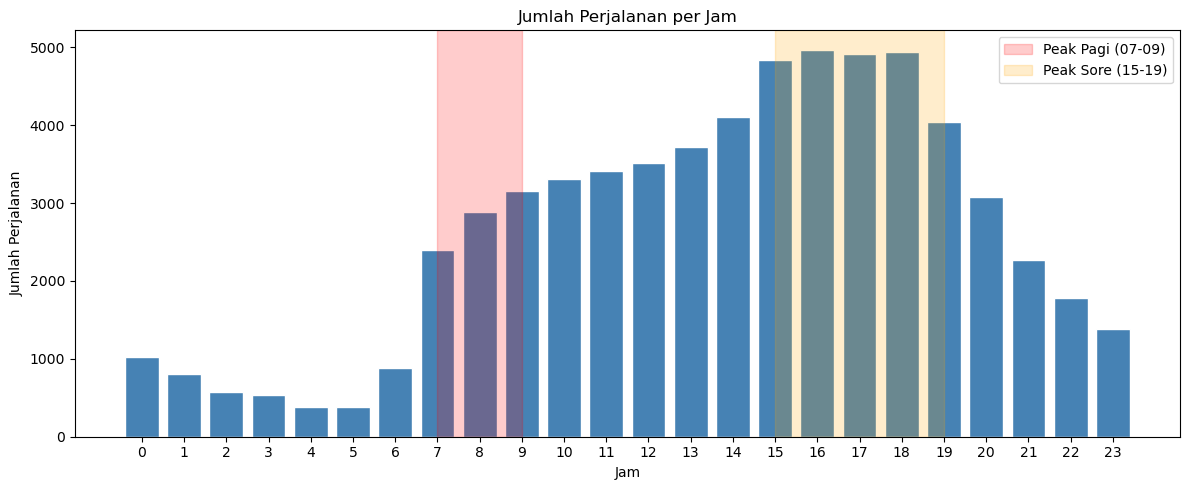

In [84]:
#Trips per Jam
trips_per_jam = df.groupby('pickup_hour').size()

plt.figure(figsize=(12, 5))
plt.bar(trips_per_jam.index, trips_per_jam.values, color='steelblue', edgecolor='white')
plt.axvspan(7, 9, alpha=0.2, color='red', label='Peak Pagi (07-09)')
plt.axvspan(15, 19, alpha=0.2, color='orange', label='Peak Sore (15-19)')
plt.title('Jumlah Perjalanan per Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Perjalanan')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()



Grafiknya menunjukan adanya lonjakan permintaan yang cukup signifikan pukul 07.00–09.00 dan 15.00–19.00, hal ini berkaitan dengan jam berangkat dan pulang kerja (commuting). Sementara itu, permintaan paling rendah ada di dini hari, sekitar pukul 02.00–05.00

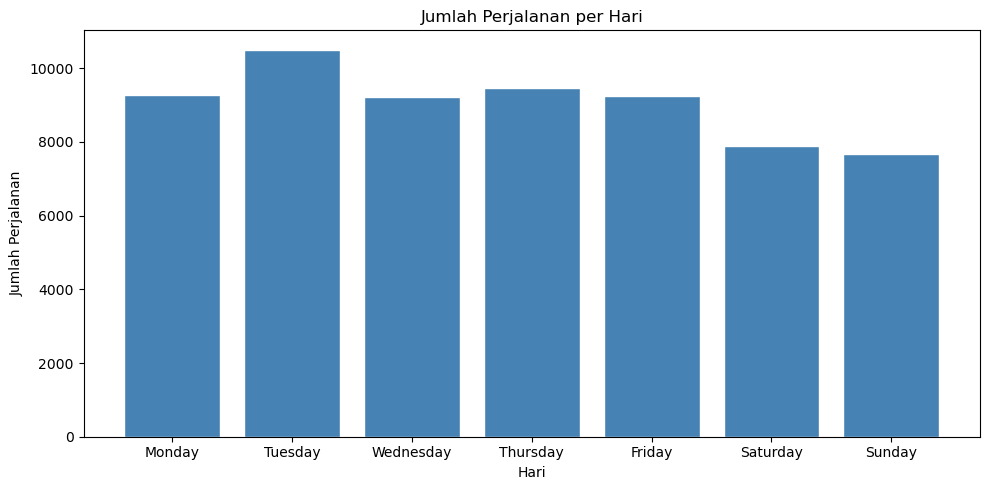

In [85]:
# Trips per Hari
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
trips_per_hari = df.groupby('pickup_day').size().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(trips_per_hari.index, trips_per_hari.values, color='steelblue', edgecolor='white')
plt.title('Jumlah Perjalanan per Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Perjalanan')
plt.tight_layout()
plt.show()

Jumlah perjalanan paling banyak terjadi pada hari kerja (Senin–Jumat), dengan puncaknya ada di hari Selasa. Sementara itu, pada hari Sabtu dan Minggu terlihat ada penurunan permintaan yang cukup signifikan, yang menunjukkan jika mayoritas pengguna layanan ini adalah komuter harian.

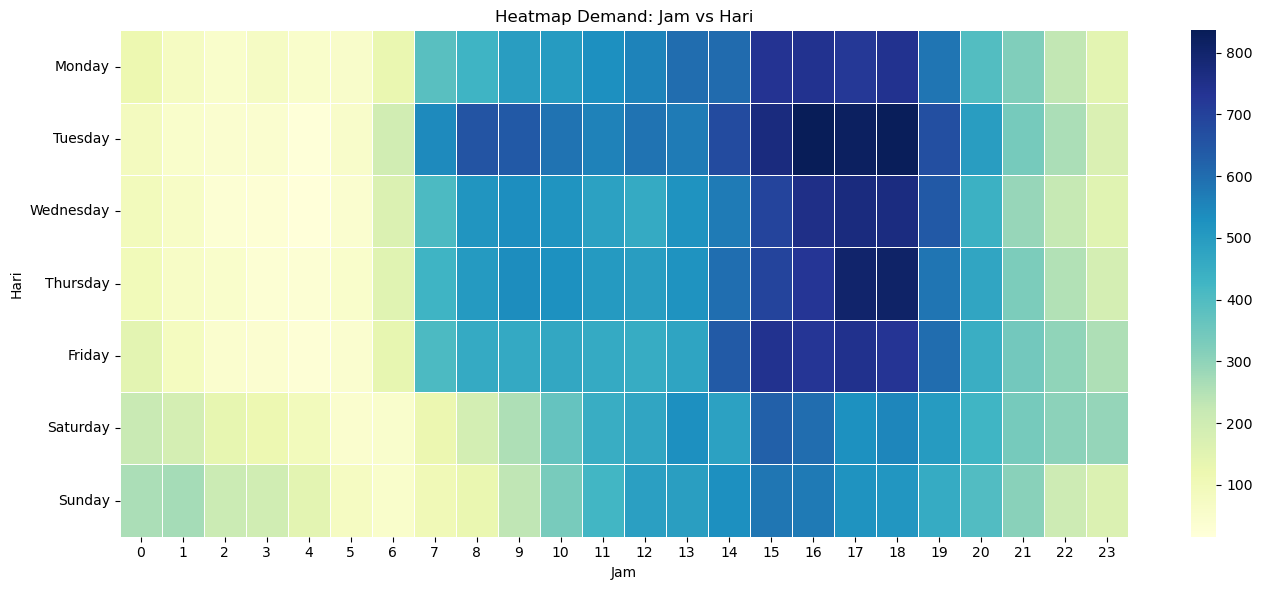

In [86]:
# Heatmap Jam × Hari
pivot = df.groupby(['pickup_day', 'pickup_hour']).size().unstack()
pivot = pivot.reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.5, annot=False)
plt.title('Heatmap Demand: Jam vs Hari')
plt.xlabel('Jam')
plt.ylabel('Hari')
plt.tight_layout()
plt.show()


Heatmap memperjelas bahwa kombinasi hari kerja dan jam sore (15–19) merupakan zona dengan demand tertinggi, yang terlihat dari warna paling gelap. Pola ini konsisten di seluruh hari kerja, sementara pada akhir pekan distribusinya cenderung lebih merata sepanjang hari.

**Kesimpulan**  
Secara keseluruhan, demand perjalanan taksi NYC TLC sangat terkonsentrasi pada jam sibuk pagi dan sore di hari kerja. Pola ini menunjukkan adanya peluang optimasi armada yang cukup jelas, yaitu dengan memfokuskan armada pada *peak hours* dan hari kerja sehingga berpotensi meningkatkan efisiensi operasional secara signifikan.

**Analisis Efisiensi Tarif**

Analisis ini digunakan untuk mengetahui efisiensi pada tiap jenis dan waktu perjalanan yang digunakan

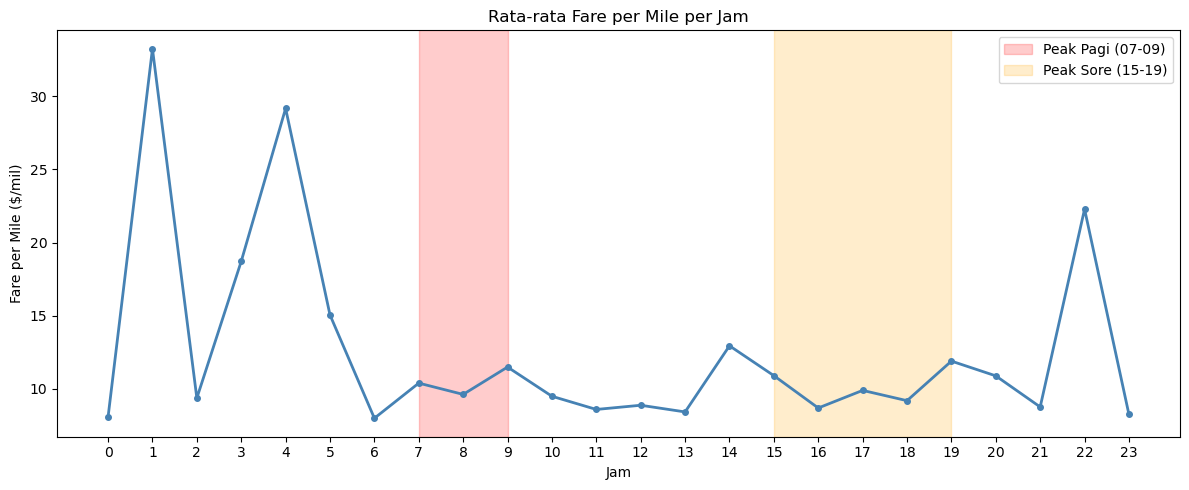

In [87]:
# Rata-rata Fare per Mile per Jam
fare_per_jam = df.groupby('pickup_hour')['fare_per_mile'].mean()

plt.figure(figsize=(12, 5))
plt.plot(fare_per_jam.index, fare_per_jam.values, 
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.axvspan(7, 9, alpha=0.2, color='red', label='Peak Pagi (07-09)')
plt.axvspan(15, 19, alpha=0.2, color='orange', label='Peak Sore (15-19)')
plt.title('Rata-rata Fare per Mile per Jam')
plt.xlabel('Jam')
plt.ylabel('Fare per Mile ($/mil)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa **fare per mile** cenderung lebih tinggi pada jam di luar *peak hour*, terutama pada dini hari (00–05) dan siang hari (10–14). Hal ini mengindikasikan bahwa perjalanan jarak pendek dengan tarif relatif tinggi lebih sering terjadi di luar *peak hour*, sementara pada *peak hour* perjalanan yang terjadi cenderung lebih panjang sehingga rasio tarif per milnya menjadi lebih rendah.

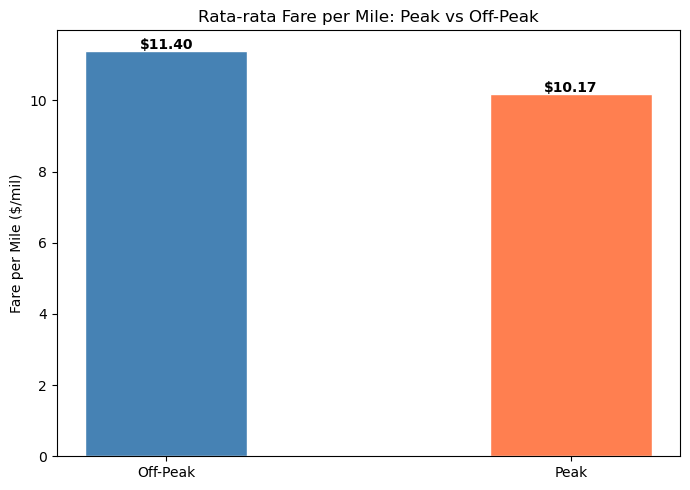

In [88]:
# Perbandingan Fare per Mile: Peak vs Off-Peak
fare_peak = df.groupby('is_peak_hour')['fare_per_mile'].mean()
fare_peak.index = ['Off-Peak', 'Peak']

plt.figure(figsize=(7, 5))
plt.bar(fare_peak.index, fare_peak.values, 
        color=['steelblue', 'coral'], edgecolor='white', width=0.4)
plt.title('Rata-rata Fare per Mile: Peak vs Off-Peak')
plt.ylabel('Fare per Mile ($/mil)')
for i, v in enumerate(fare_peak.values):
    plt.text(i, v + 0.05, f'${v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Perbandingan langsung menunjukkan bahwa fare per mile pada *off-peak* lebih tinggi dibanding *peak hour*. Hal ini terjadi karena pada *peak hour* kemacetan membuat durasi perjalanan jadi lebih lama tanpa menambah jarak tempuh, sehingga efisiensi fare per mile justru menurun.

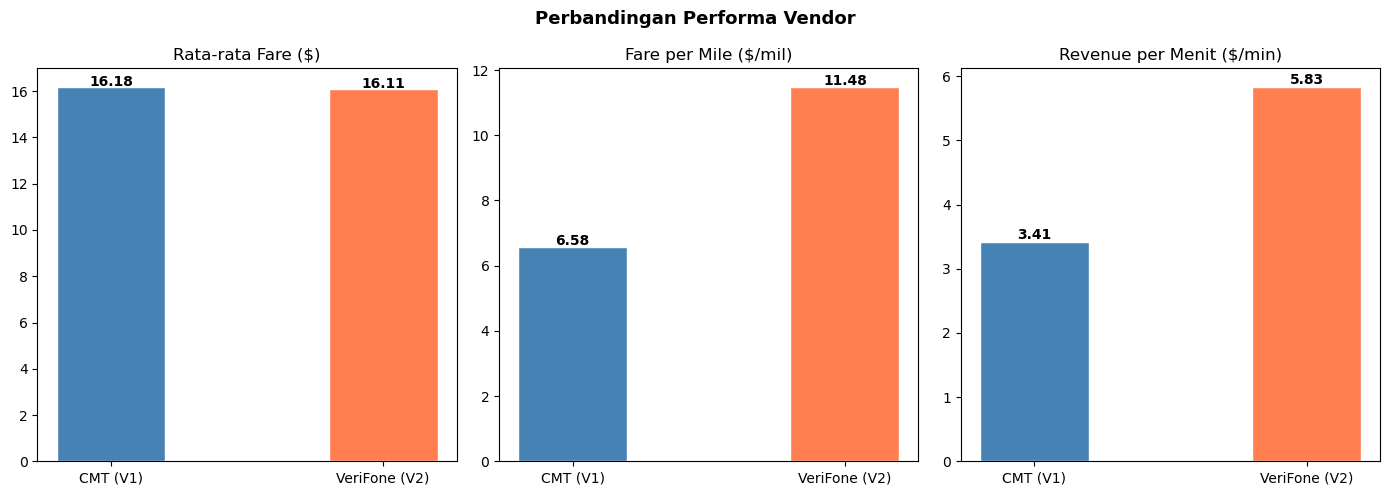

In [89]:
# Perbandingan Performa Vendor
vendor_stats = df.groupby('VendorID').agg(
    jumlah_trip    = ('fare_amount', 'count'),
    rata_fare      = ('fare_amount', 'mean'),
    rata_jarak     = ('trip_distance', 'mean'),
    rata_durasi    = ('trip_duration_min', 'mean'),
    rata_fare_mile = ('fare_per_mile', 'mean'),
    rata_rev_min   = ('revenue_per_minute', 'mean')
).round(2)

vendor_stats.index = ['CMT (V1)', 'VeriFone (V2)']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Perbandingan Performa Vendor', fontsize=13, fontweight='bold')

metrics = ['rata_fare', 'rata_fare_mile', 'rata_rev_min']
labels  = ['Rata-rata Fare ($)', 'Fare per Mile ($/mil)', 'Revenue per Menit ($/min)']

for i, (metric, label) in enumerate(zip(metrics, labels)):
    axes[i].bar(vendor_stats.index, vendor_stats[metric], 
                color=['steelblue', 'coral'], edgecolor='white', width=0.4)
    axes[i].set_title(label)
    for j, v in enumerate(vendor_stats[metric]):
        axes[i].text(j, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Secara volume, **VeriFone (V2)** mendominasi jumlah trip secara signifikan dibanding **CMT (V1)**. Namun dari sisi efisiensi, kedua vendor menunjukkan nilai *fare per mile* dan *revenue per minute* yang relatif sebanding, yang berarti **CMT** tetap mampu mempertahankan efisiensi meskipun volumenya lebih rendah.

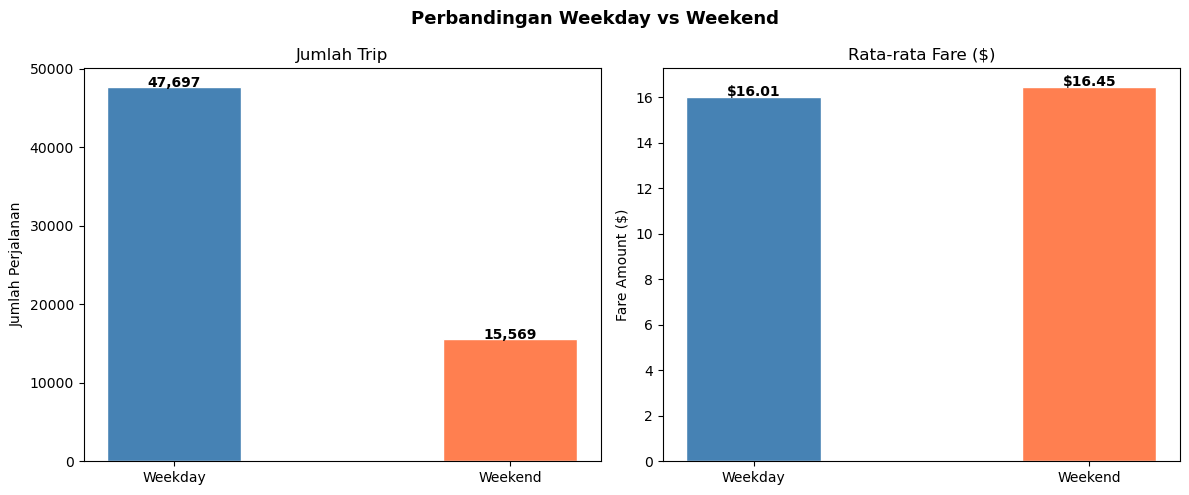

In [90]:
# Weekend vs Weekday
weekend_stats = df.groupby('is_weekend').agg(
    jumlah_trip    = ('fare_amount', 'count'),
    rata_fare      = ('fare_amount', 'mean'),
    rata_fare_mile = ('fare_per_mile', 'mean'),
    rata_durasi    = ('trip_duration_min', 'mean')
).round(2)

weekend_stats.index = ['Weekday', 'Weekend']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Perbandingan Weekday vs Weekend', fontsize=13, fontweight='bold')

# Jumlah trip
axes[0].bar(weekend_stats.index, weekend_stats['jumlah_trip'],
            color=['steelblue', 'coral'], edgecolor='white', width=0.4)
axes[0].set_title('Jumlah Trip')
axes[0].set_ylabel('Jumlah Perjalanan')
for i, v in enumerate(weekend_stats['jumlah_trip']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Rata-rata fare
axes[1].bar(weekend_stats.index, weekend_stats['rata_fare'],
            color=['steelblue', 'coral'], edgecolor='white', width=0.4)
axes[1].set_title('Rata-rata Fare ($)')
axes[1].set_ylabel('Fare Amount ($)')
for i, v in enumerate(weekend_stats['rata_fare']):
    axes[1].text(i, v + 0.05, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


*Weekday* menghasilkan volume trip yang jauh lebih tinggi dibanding *weekend*. Namun, rata-rata fare per perjalanan pada *weekend* cenderung sedikit lebih tinggi, yang kemungkinan disebabkan karena perjalanan di *weekend* lebih bersifat *leisure* dengan jarak yang relatif lebih jauh.


**Kesimpulan**  
Analisis efisiensi tarif menunjukkan bahwa *fare per mile* tidak selalu paling tinggi pada *peak hour*. Justru, kemacetan pada *peak hour* membuat durasi perjalanan bertambah tanpa diikuti peningkatan jarak, sehingga efisiensi tarif per mil menjadi lebih rendah.

Dari sisi vendor, **VeriFone** unggul dalam volume perjalanan, sementara **CMT** tetap menunjukkan efisiensi yang kompetitif. Temuan ini mengindikasikan perlunya strategi tarif yang lebih dinamis dengan mempertimbangkan kondisi lalu lintas, bukan hanya waktu, sehingga *revenue per minute* dapat dioptimalkan baik pada *peak hour* maupun *off-peak*.


**Analisis Zona Pickup**

Analisis ini bertujuan untuk mengetahui zona manakah yang paling menguntungkan

In [91]:
# Top 10 Zona Pickup Berdasarkan Volume Trip
top_pu = df.groupby('PULocationID').agg(
    jumlah_trip    = ('fare_amount', 'count'),
    rata_fare      = ('fare_amount', 'mean'),
    rata_fare_mile = ('fare_per_mile', 'mean'),
    total_revenue  = ('total_amount', 'sum')
).round(2).sort_values('jumlah_trip', ascending=False).head(10)

# Gabung dengan nama zona
top_pu = top_pu.merge(zone_lookup[['LocationID', 'Zone']], 
                       left_index=True, right_on='LocationID').set_index('Zone')

top_pu

,jumlah_trip,rata_fare,rata_fare_mile,total_revenue,LocationID
Zone,,,,,
East Harlem North,12928,13.90,7.67,248358.28,74
East Harlem South,8818,13.93,8.59,175472.41,75
Forest Hills,3795,15.07,11.16,72304.06,95
Central Harlem,3720,13.29,9.18,65348.13,41
Morningside Heights,3595,15.07,8.22,75602.54,166
Elmhurst,2857,16.66,17.73,60973.15,82
Central Park,2846,14.77,7.42,63155.45,43
Fort Greene,2126,16.53,8.78,45455.80,97
Astoria,1803,15.58,12.21,35985.36,7


Tabel menunjukkan zona-zona dengan permintaan tertinggi terkonsentrasi di beberapa wilayah tertentu. Zona **East Harlem North** memimpin dengan total jumlah trip sebanyak **12.928**, mengindikasikan titik demand yang konsisten dan perlu diprioritaskan dalam distribusi armada.

Hal ini menunjukkan bahwa **East Harlem North** merupakan area dengan aktivitas mobilitas yang tinggi, sehingga penyedia layanan transportasi perlu memastikan ketersediaan kendaraan yang memadai di zona tersebut. Dengan begitu, waktu tunggu dapat ditekan dan efisiensi operasional dapat meningkat, terutama pada jam-jam sibuk.

In [92]:
# Top 10 Zona Paling Menguntungkan (Revenue Tertinggi)
top_revenue = df.groupby('PULocationID').agg(
    total_revenue  = ('total_amount', 'sum'),
    rata_fare_mile = ('fare_per_mile', 'mean'),
    jumlah_trip    = ('fare_amount', 'count')
).round(2).sort_values('total_revenue', ascending=False).head(10)

top_revenue = top_revenue.merge(zone_lookup[['LocationID', 'Zone']], 
                                 left_index=True, right_on='LocationID').set_index('Zone')
top_revenue


,total_revenue,rata_fare_mile,jumlah_trip,LocationID
Zone,,,,
East Harlem North,248358.28,7.67,12928,74
East Harlem South,175472.41,8.59,8818,75
Morningside Heights,75602.54,8.22,3595,166
Forest Hills,72304.06,11.16,3795,95
Central Harlem,65348.13,9.18,3720,41
Central Park,63155.45,7.42,2846,43
Elmhurst,60973.15,17.73,2857,82
Washington Heights South,49921.30,6.53,1623,244
Fort Greene,45455.80,8.78,2126,97


Zona dengan revenue tertinggi tidak selalu sama dengan zona dengan efisiensi tarif tertinggi. Zona **East Harlem North** menghasilkan total **revenue tertinggi**, yang didorong oleh **volume trip yang sangat besar**. Namun, jika dilihat dari sisi **rata-rata fare per mile**, zona ini masih **kalah dibandingkan dengan Elmhurst** yang memiliki nilai **fare per mile lebih tinggi**.

Hal ini menunjukkan bahwa meskipun **East Harlem North unggul dari sisi jumlah perjalanan (volume-driven revenue)**, perjalanan di **Elmhurst secara individu lebih menguntungkan (value per trip lebih tinggi)**. Dengan kata lain, **Elmhurst mencerminkan efisiensi tarif yang lebih baik**, sementara **East Harlem North mencerminkan kekuatan dari tingginya permintaan**.

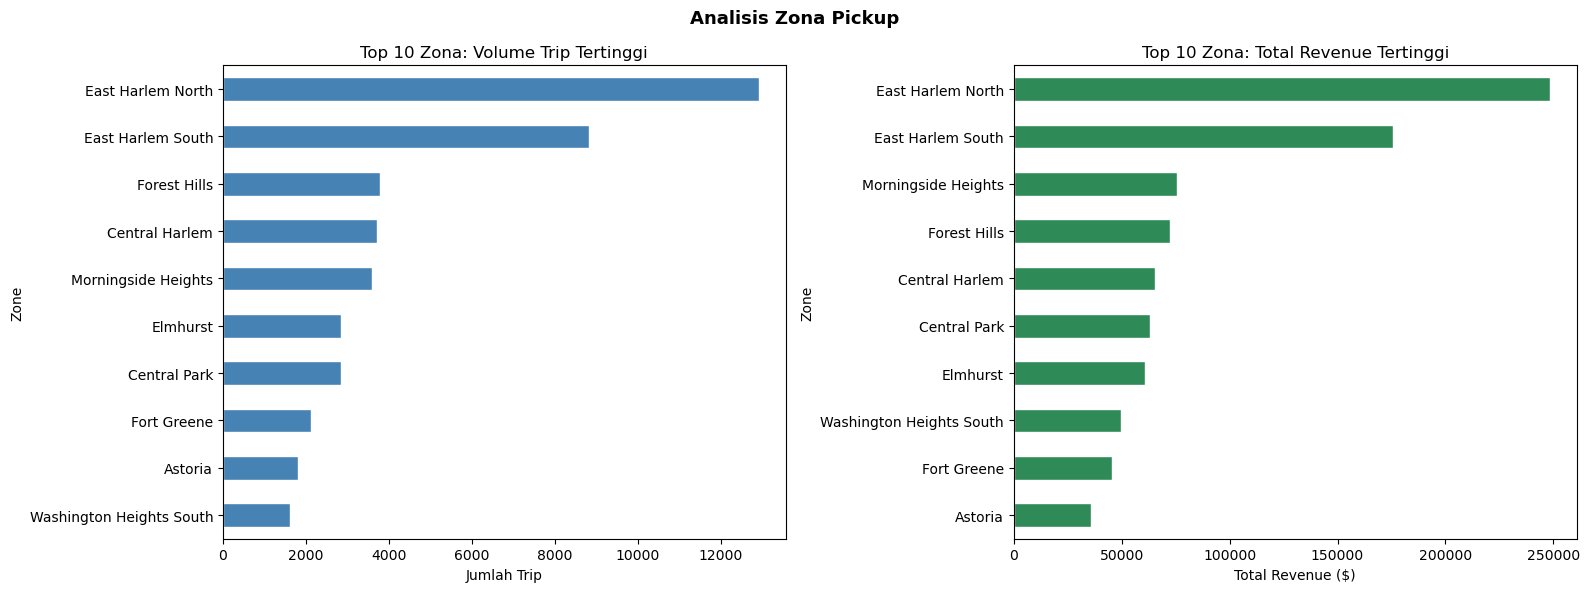

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Zona Pickup', fontsize=13, fontweight='bold')

# Volume trip per zona
top_pu['jumlah_trip'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Zona: Volume Trip Tertinggi')
axes[0].set_xlabel('Jumlah Trip')

# Revenue per zona
top_revenue['total_revenue'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Top 10 Zona: Total Revenue Tertinggi')
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()


Visualisasi mempertegas bahwa terdapat gap yang jelas antara zona dengan volume trip tinggi dan zona dengan profitabilitas tinggi. Zona seperti **East Harlem North** **mendominasi** dari **sisi jumlah trip sekaligus total revenue** karena tingginya permintaan. Namun, tidak semua zona dengan revenue tinggi berasal dari volume yang besar.

Beberapa zona di sisi kanan chart revenue seperti **Elmhurst tidak termasuk dalam volume trip tertinggi, tetapi tetap mampu menghasilkan revenue yang relatif besar**. Hal ini menunjukkan bahwa **kualitas trip berupa fare per mile di zona tersebut lebih tinggi**, sehingga setiap perjalanan memberikan kontribusi pendapatan yang lebih besar.

Dengan demikian, **profitabilitas tidak hanya ditentukan oleh kuantitas perjalanan, tetapi juga oleh efisiensi tarif**. Zona dengan **volume tinggi** cocok untuk strategi **ekspansi armada**, sementara zona dengan **fare per mile tinggi** lebih potensial untuk **memaksimalkan margin per trip**.

**Armada perlu diprioritaskan ke zona East Harlem North sebagai pusat demand utama, serta ke zona seperti Elmhurst yang memiliki margin per trip tinggi, terutama pada jam peak hour untuk memaksimalkan revenue operasional.**

## Uji Statistik Inferensial

Pengujian ini dilakukan untuk menguji faktor-faktor yang memengaruhi tarif dan efisiensi pendapatan perjalanan (fare), baik dari sisi waktu (peak hour), jarak, maupun perbedaan antar vendor.

In [94]:
# Mann-Whitney Peak vs Off-Peak
peak    = df[df['is_peak_hour'] == 1]['fare_per_mile']
offpeak = df[df['is_peak_hour'] == 0]['fare_per_mile']

stat, p = stats.mannwhitneyu(peak, offpeak, alternative='two-sided')

print(f"Mann-Whitney U Statistic : {stat:.2f}")
print(f"P-value                  : {p:.4f}")
print()
if p < 0.05:
    print("Kesimpulan: Terdapat perbedaan signifikan fare_per_mile antara peak dan off-peak (p < 0.05)")
else:
    print("Kesimpulan: Tidak terdapat perbedaan signifikan fare_per_mile antara peak dan off-peak (p >= 0.05)")

Mann-Whitney U Statistic : 557870279.00
P-value                  : 0.0000

Kesimpulan: Terdapat perbedaan signifikan fare_per_mile antara peak dan off-peak (p < 0.05)


Hasil uji Mann-Whitney menunjukkan **U = 557.870.279** dengan **p-value = 0.0000 (< 0.05)**, sehingga **H0 ditolak**. Artinya, terdapat **perbedaan signifikan** fare per mile antara *peak hour* dan *off-peak*.

Temuan ini menunjukkan bahwa ***peak hour* menurunkan efisiensi tarif per mil akibat kemacetan**, sehingga ***off-peak* lebih optimal dari sisi revenue per mile**.

In [95]:
# Pearson Correlation
corr, p = stats.pearsonr(df['trip_distance'], df['fare_amount'])

print(f"Pearson Correlation (r) : {corr:.4f}")
print(f"P-value                 : {p:.4f}")
print()
if corr >= 0.7:
    print("Korelasi kuat — jarak adalah prediktor utama tarif")
elif corr >= 0.4:
    print("Korelasi sedang — jarak berpengaruh tapi ada faktor lain")
else:
    print("Korelasi lemah — tarif dipengaruhi faktor selain jarak")


Pearson Correlation (r) : 0.3286
P-value                 : 0.0000

Korelasi lemah — tarif dipengaruhi faktor selain jarak


Korelasi Pearson antara *trip_distance* dan *fare_amount* menghasilkan **r = 0.3286** dengan **p-value = 0.0000**, sehingga hubungan keduanya **signifikan namun lemah**.

Artinya, **jarak bukan satu-satunya penentu tarif**. Faktor lain seperti **kemacetan, surcharge, rate code, dan durasi perjalanan** juga berperan besar dalam menentukan besarnya fare.


In [96]:
# Mann-Whitney Vendor 1 vs Vendor 2

v1 = df[df['VendorID'] == 1]['fare_amount']
v2 = df[df['VendorID'] == 2]['fare_amount']

stat, p = stats.mannwhitneyu(v1, v2, alternative='two-sided')

print(f"Mann-Whitney U Statistic : {stat:.2f}")
print(f"P-value                  : {p:.4f}")
print()
if p < 0.05:
    print("Kesimpulan: Terdapat perbedaan signifikan fare_amount antara Vendor 1 dan Vendor 2 (p < 0.05)")
else:
    print("Kesimpulan: Tidak terdapat perbedaan signifikan fare_amount antara Vendor 1 dan Vendor 2 (p >= 0.05)")


Mann-Whitney U Statistic : 246527956.50
P-value                  : 0.7771

Kesimpulan: Tidak terdapat perbedaan signifikan fare_amount antara Vendor 1 dan Vendor 2 (p >= 0.05)


Hasil uji Mann-Whitney menunjukkan **U = 246.527.956,50** dengan **p-value = 0.7771 (> 0.05)**, sehingga **H0 gagal ditolak**. Artinya, **tidak ada perbedaan signifikan** *fare_amount* antara Vendor 1 (CMT) dan Vendor 2 (VeriFone).

Dengan demikian, **struktur tarif keduanya relatif setara**, sehingga persaingan lebih terjadi pada **layanan dan jangkauan**, bukan pada harga.


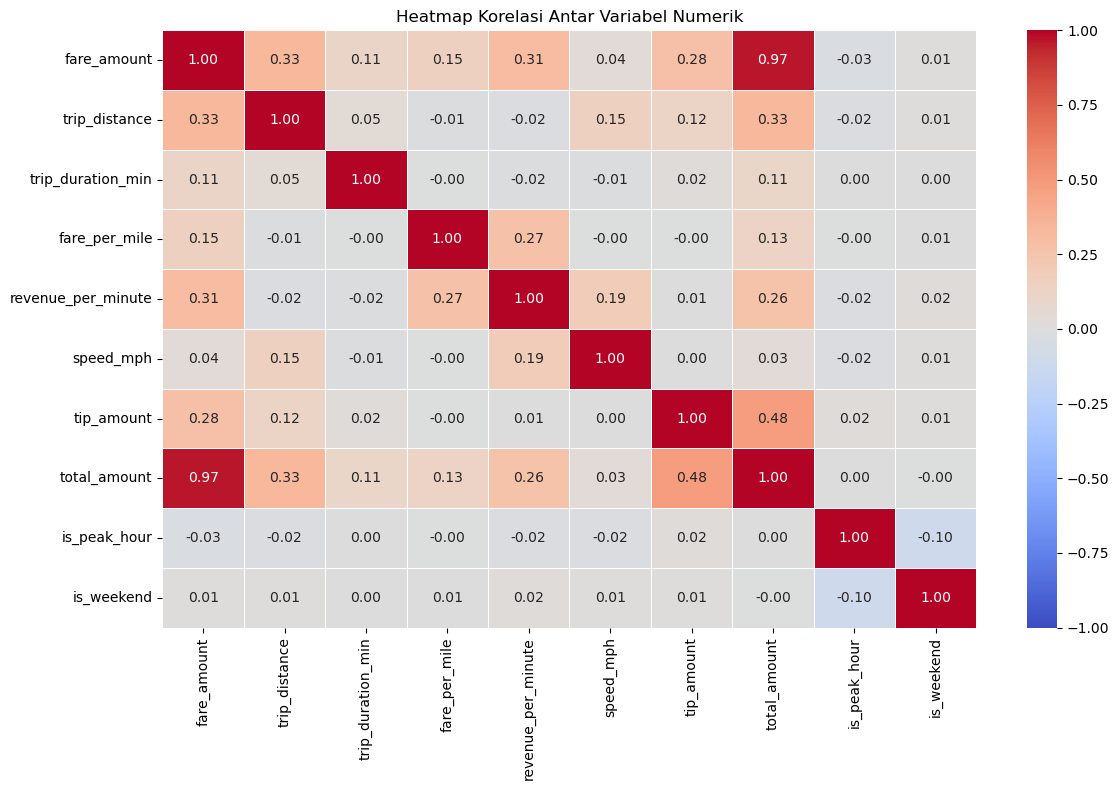

In [97]:
# Heatmap Korelasi
kolom_numerik = ['fare_amount', 'trip_distance', 'trip_duration_min', 
                 'fare_per_mile', 'revenue_per_minute', 'speed_mph',
                 'tip_amount', 'total_amount', 'is_peak_hour', 'is_weekend']

plt.figure(figsize=(12, 8))
sns.heatmap(df[kolom_numerik].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.tight_layout()
plt.show()


Heatmap menunjukkan korelasi paling kuat antara **fare_amount dan total_amount (r = 0.97)**, yang wajar karena *total_amount* merupakan turunan langsung dari *fare_amount*. Korelasi berikutnya terlihat pada **tip_amount terhadap total_amount (r = 0.48)**, menandakan tip cukup berkontribusi terhadap total pendapatan per trip.

Sebaliknya, **is_peak_hour** dan **is_weekend** memiliki korelasi yang sangat lemah terhadap variabel finansial, sehingga **waktu perjalanan saja tidak cukup menjelaskan variasi tarif**.


**Kesimpulan**  
Dari ketiga uji statistik, ditemukan bahwa **peak hour berpengaruh signifikan terhadap efisiensi fare per mile (p < 0.05)**. Namun, **korelasi antara jarak dan tarif tergolong lemah (r = 0.33)**, sehingga tarif dipengaruhi banyak faktor selain jarak.

Selain itu, **tidak terdapat perbedaan signifikan antar vendor (p = 0.78)**, yang menunjukkan bahwa persaingan tidak terjadi pada level harga.

Heatmap juga mempertegas bahwa **optimasi revenue lebih efektif difokuskan pada peningkatan tip dan efisiensi tarif**, bukan hanya menambah volume trip.


## Kesimpulan dan Rekomendasi

**Rekomendasi 1: Dynamic Pricing pada Peak Hour**  
Terapkan **surge pricing multiplier 1,3x** pada jam **07.00–09.00** dan **15.00–19.00** untuk mengkompensasi penurunan efisiensi tarif selama jam sibuk.

**Dasar data:** Uji Mann-Whitney menunjukkan *fare per mile* saat **peak hour** berbeda signifikan (**p < 0.05**) dan cenderung lebih rendah dibanding **off-peak** akibat kemacetan.

In [98]:
# Rata-rata fare peak vs off-peak saat ini
avg_fare_peak    = df[df['is_peak_hour'] == 1]['fare_amount'].mean()
avg_fare_offpeak = df[df['is_peak_hour'] == 0]['fare_amount'].mean()

# Proyeksi: naikkan fare peak setara off-peak fare_per_mile
avg_fpm_peak    = df[df['is_peak_hour'] == 1]['fare_per_mile'].mean()
avg_fpm_offpeak = df[df['is_peak_hour'] == 0]['fare_per_mile'].mean()

# Multiplier berdasarkan selisih fare_per_mile off-peak vs peak
multiplier   = avg_fpm_offpeak / avg_fpm_peak
proyeksi     = avg_fare_peak * multiplier
peningkatan  = ((proyeksi - avg_fare_peak) / avg_fare_peak) * 100

print(f"Rata-rata fare peak saat ini     : ${avg_fare_peak:.2f}")
print(f"Rata-rata fare_per_mile peak     : ${avg_fpm_peak:.4f}")
print(f"Rata-rata fare_per_mile off-peak : ${avg_fpm_offpeak:.4f}")
print(f"Multiplier dari data             : {multiplier:.2f}x")
print(f"Proyeksi fare setelah adjustment : ${proyeksi:.2f}")
print(f"Estimasi peningkatan revenue     : +{peningkatan:.1f}%")


Rata-rata fare peak saat ini     : $15.75
Rata-rata fare_per_mile peak     : $10.1713
Rata-rata fare_per_mile off-peak : $11.3980
Multiplier dari data             : 1.12x
Proyeksi fare setelah adjustment : $17.65
Estimasi peningkatan revenue     : +12.1%


**Rekomendasi 2: Optimasi Distribusi Armada Berdasarkan Zona**  
Prioritaskan distribusi armada ke zona dengan **kombinasi volume trip tinggi dan *fare per mile* tinggi**, khususnya pada **jam peak hour** untuk memaksimalkan revenue operasional.

**Dasar data:** Analisis zona menunjukkan bahwa **volume trip tidak selalu sejalan dengan profitabilitas**, sehingga terdapat gap antara zona sibuk dan zona yang lebih menguntungkan.

In [99]:
zona_optimal = df.groupby('PULocationID').agg(
    jumlah_trip    = ('fare_amount', 'count'),
    rata_fare_mile = ('fare_per_mile', 'mean'),
    total_revenue  = ('total_amount', 'sum')
).round(2)

zona_optimal['skor'] = (
    (zona_optimal['jumlah_trip'] / zona_optimal['jumlah_trip'].max()) +
    (zona_optimal['rata_fare_mile'] / zona_optimal['rata_fare_mile'].max())
) / 2

top_zona    = zona_optimal.sort_values('skor', ascending=False).head(5)
bawah_zona  = zona_optimal.sort_values('skor', ascending=True).head(5)

revenue_top   = top_zona['total_revenue'].mean()
revenue_bawah = bawah_zona['total_revenue'].mean()
peningkatan   = ((revenue_top - revenue_bawah) / revenue_bawah) * 100

top_zona = top_zona.merge(zone_lookup[['LocationID', 'Zone']], 
                           left_index=True, right_on='LocationID').set_index('Zone')
display(top_zona)

print(f"Rata-rata revenue top 5 zona optimal  : ${revenue_top:,.2f}")
print(f"Rata-rata revenue bottom 5 zona       : ${revenue_bawah:,.2f}")
print(f"Estimasi peningkatan jika armada      ")
print(f"dipindah dari zona bawah ke optimal   : +{peningkatan:.1f}%")


,jumlah_trip,rata_fare_mile,total_revenue,skor,LocationID
Zone,,,,,
East Harlem North,12928,7.67,248358.28,0.525369,74
JFK Airport,12,151.17,502.82,0.500464,132
Bronx Park,2,145.02,61.69,0.479736,31
West Farms/Bronx River,12,136.54,307.20,0.452075,248
Mount Hope,39,127.63,913.91,0.423649,169


Rata-rata revenue top 5 zona optimal  : $50,028.78
Rata-rata revenue bottom 5 zona       : $135.00
Estimasi peningkatan jika armada      
dipindah dari zona bawah ke optimal   : +36958.9%


**Rekomendasi 3: Optimasi Struktur Tarif Berbasis Faktor Non-Jarak**
Revisi struktur tarif dengan menambahkan komponen berbasis **durasi (per menit)** yang lebih proporsional, khususnya untuk perjalanan di **zona dengan tingkat kemacetan tinggi**.

**Dasar data:** Korelasi Pearson antara **jarak dan tarif hanya r = 0.33 (lemah)**, sehingga tarif lebih banyak dipengaruhi faktor lain seperti **durasi perjalanan, surcharge, dan kondisi lalu lintas**.


In [100]:
# Bandingkan revenue_per_minute trip pendek vs panjang
median_durasi = df['trip_duration_min'].median()

trip_pendek = df[df['trip_duration_min'] <= median_durasi]['revenue_per_minute'].mean()
trip_panjang = df[df['trip_duration_min'] > median_durasi]['revenue_per_minute'].mean()
peningkatan  = ((trip_pendek - trip_panjang) / trip_panjang) * 100

print(f"Revenue per menit trip pendek  : ${trip_pendek:.4f}")
print(f"Revenue per menit trip panjang : ${trip_panjang:.4f}")
print(f"Selisih efisiensi              : {peningkatan:.1f}%")
print()
print("Rekomendasi: tambahkan komponen tarif per menit pada trip panjang")
print(f"untuk menutup gap efisiensi sebesar {abs(peningkatan):.1f}%")


Revenue per menit trip pendek  : $9.4703
Revenue per menit trip panjang : $1.4806
Selisih efisiensi              : 539.6%

Rekomendasi: tambahkan komponen tarif per menit pada trip panjang
untuk menutup gap efisiensi sebesar 539.6%


**Rekomendasi 4: Mendorong Pembayaran Digital untuk Capture Tip**
Dorong konversi pembayaran dari cash ke digital melalui program insentif, misalnya **diskon 5% untuk pengguna baru kartu kredit atau dompet digital**, agar potensi tip dapat tercatat dan meningkatkan revenue.

**Dasar data:** Heatmap menunjukkan **tip_amount memiliki korelasi cukup kuat dengan total_amount (r = 0.48)**, namun **lebih dari 35% transaksi masih menggunakan cash** sehingga tip tidak terekam secara optimal.


In [101]:
# Tip rata-rata dari kartu kredit
avg_tip_cc  = df[df['payment_type'] == 1]['tip_amount'].mean()
avg_tip_cash = df[df['payment_type'] == 2]['tip_amount'].mean()
cash_trips  = df[df['payment_type'] == 2].shape[0]
total_rev   = df['total_amount'].sum()

# Berapa persen cash trips dari total
pct_cash = (cash_trips / len(df)) * 100

# Jika seluruh cash beralih ke digital, tip yang bisa dicapture
potensi_tip  = cash_trips * avg_tip_cc
pct_increase = (potensi_tip / total_rev) * 100

print(f"Proporsi transaksi cash          : {pct_cash:.1f}%")
print(f"Rata-rata tip kartu kredit       : ${avg_tip_cc:.2f}")
print(f"Rata-rata tip cash (tercatat)    : ${avg_tip_cash:.2f}")
print(f"Potensi tip jika semua ke digital: ${potensi_tip:,.2f}")
print(f"Estimasi peningkatan revenue     : +{pct_increase:.1f}%")


Proporsi transaksi cash          : 35.6%
Rata-rata tip kartu kredit       : $3.21
Rata-rata tip cash (tercatat)    : $0.00
Potensi tip jika semua ke digital: $72,180.70
Estimasi peningkatan revenue     : +5.4%


## Kesimpulan Akhir  
Secara keseluruhan, peningkatan **revenue dan efisiensi operasional NYC TLC tidka bisa cuma mengandalkan volume trip**, tapi harus memakai strategi yang berbasis data. Dari hasil analisis, terlihat jika **peak hour membuat efisiensi *fare per mile* turun dengan signifikan (p < 0.05)**, **hubungan jarak dan tarif juga terhitung lemah (r = 0.33)**, dan **lebih dari 35% transaksi masih menggunakan cash** sehingga banyak potensi tip belum *tercapture* maksimal.

Oleh karena itu, jika menerapkan ke 4 rekomendasi secara bersamaan seperti **dynamic pricing, optimasi zona armada, tarif berbasis durasi, dan pembayaran digital**, operasional bisa menjadi **lebih efisien dan revenue per trip lebih optimal**. Keempat strategi ini saling melengkapi, jadi menjadi efektif jika dijalankan **secara bersamaan**.


In [102]:
# export datafram yang sudah diolah
df.to_excel('NYC-TLC-Cleaned-Final.xlsx', index=False)